# Founder Exit and Repo Survival

This notebook demonstrates the core pipeline from `method.py`: an implementation of Avelino et al.'s (ESEM 2019) **Degree-of-Authorship (DOA) / Truck-Factor (TF) / Truck-Factor-Developer-Departure (TFDD)** recomputation on real GitHub repositories, plus a **new pre-departure authority-diffusion measurement** that tests whether it predicts post-departure survival better than Avelino et al.'s null snapshot covariates (stars, forks, contributor count).

**What this demo does:**
1. Loads pre-extracted `(author, file, timestamp)` commit event logs for 6 small/medium real GitHub repos (mined the same way the original script does: `git log --name-only` over a blobless clone, plus the GitHub REST API for stars/forks/license).
2. Recomputes DOA scores and quarterly Truck-Factor snapshots per repo (verbatim Fritz/Avelino formula).
3. Finds each repo's founder-only TFDD event (the truck-factor collapses to just the founder, who then goes silent for 12+ months).
4. Computes the new authority-diffusion signal (founder commit-share + count of independent non-founder DOA file-owners) in the 6-12 month window before the TFDD.
5. Computes the survival outcome (does a new non-founder developer reach truck-factor status afterward?) and runs the same logistic-regression / matched-pairs / placebo analyses as the full experiment.

**Note on scale:** the full experiment mines 62 curated repos via live `git clone` + GitHub API calls (network- and compute-heavy, ~minutes per repo). This demo instead loads pre-extracted commit logs for 6 of those repos from `mini_demo_data.json`, so it runs in well under a minute with no network dependency during analysis, while running the *exact same* DOA/TF/TFDD/diffusion/survival/regression code as the original.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru -- NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, statsmodels -- pre-installed on Colab, install locally to match Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'statsmodels==0.14.6', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import math
import random
import re
import sys
from dataclasses import dataclass, field
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import statsmodels.api as sm
from loguru import logger
from scipy import stats as spstats
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Loading the demo data

`mini_demo_data.json` holds pre-extracted `(author, file, timestamp)` commit event logs (mined with the identical `git log --no-merges --name-only` + GitHub-noreply-email alias resolution as the original `extract_commits`/`canonical_author` functions) for 6 curated repos from the original 62-repo `REPO_LIST`, plus their GitHub metadata (stars, forks, language, license). We try the GitHub raw URL first (works once this artifact is published), then fall back to the local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-24ffbe-pre-departure-bus-factor-diffusion/main/round-1/experiment-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            remote = json.loads(response.read().decode())
        if isinstance(remote, dict) and remote:
            return remote
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data)} repos: {list(data.keys())}")
for repo, d in data.items():
    print(f"  {repo}: {len(d['commits'])} commits, stars={d['gh_meta'].get('stargazers_count')}")

Loaded 6 repos: ['square/retrofit', 'chartjs/Chart.js', 'junit-team/junit4', 'spf13/viper', 'urfave/cli', 'catchorg/Catch2']
  square/retrofit: 1842 commits, stars=43933
  chartjs/Chart.js: 3993 commits, stars=67655
  junit-team/junit4: 2122 commits, stars=8519
  spf13/viper: 891 commits, stars=30440
  urfave/cli: 2564 commits, stars=24197
  catchorg/Catch2: 4581 commits, stars=21431


## Config

All tunable parameters from the original script, reused verbatim (constants, not "improved"). `N_PLACEBO` and the per-repo placebo-window count are the two knobs we shrink for a fast demo -- everything else (the DOA formula, TFDD detection windows, snapshot cadence) is identical to the full run.

In [5]:
# --- constants reused verbatim from method.py ---
DOA_THRESHOLD = 3.293  # FA=0, DL=0, AC=0 baseline -> the paper's authorship cutoff
YEAR_S = 365.25 * 86400
MONTH_S = YEAR_S / 12
SNAPSHOT_STEP_MONTHS = 3  # quarterly, per fallback_plan item (3): compute-cost mitigation
MIN_HISTORY_YEARS = 3.0  # >=1yr pre-window + TFDD + 1.5yr post-window without censoring
PRE_WINDOW_START_MO = 12
PRE_WINDOW_END_MO = 6
POST_SURVIVAL_MO = 18
SILENCE_THRESHOLD_MO = 12  # Avelino et al.'s empirically-best TFDD silence window
RNG_SEED = 20260821

SOURCE_EXT = {
    ".js": "JavaScript", ".jsx": "JavaScript", ".ts": "JavaScript", ".mjs": "JavaScript", ".cjs": "JavaScript",
    ".py": "Python", ".rb": "Ruby", ".php": "PHP", ".java": "Java",
    ".cpp": "C++", ".cc": "C++", ".cxx": "C++", ".hpp": "C++", ".h": "C++",
    ".go": "Go", ".c": "C++",
}
SOURCE_FRACTION_THRESHOLD = 0.40
NAME_EXCLUDE_RE = re.compile(
    r"(^|[-_/])(awesome|book|books|course|interview-questions|docs?)([-_/]|$)", re.I
)

# --- demo-only knobs (shrunk from the full run for a fast demo) ---
N_NULL_WINDOWS_PER_REPO = 8   # original default; each is cheap so we keep it
N_PLACEBO = 25                # original N_PLACEBO=200 target -> the grouping logic below already
                               # caps draws at 25 for a corpus this size (see run_placebo below);
                               # kept explicit here as the tunable knob to scale up with more repos

## Stage 2: incremental DOA state

`FileEvents` builds a chronological `(timestamp, author)` event list per file, then computes each file's Degree-of-Authorship table (the Fritz/Avelino formula: `3.293 + 1.098*FA - 0.164*ln(1+DL) + 0.321*ln(1+AC)`) as of any point in time. `primary_owners` and `truck_factor` are the greedy Truck-Factor computation, unchanged from the original.

In [6]:
class FileEvents:
    """Chronological (ts, author) events per file, built incrementally."""

    __slots__ = ("events",)

    def __init__(self):
        self.events: dict[str, list[tuple[float, str]]] = {}

    def add(self, f: str, ts: float, author: str):
        self.events.setdefault(f, []).append((ts, author))

    def doa_table(self, up_to_ts: float) -> dict[str, dict[str, float]]:
        """Return {file: {author: DOA}} using events with ts <= up_to_ts."""
        out: dict[str, dict[str, float]] = {}
        for f, evs in self.events.items():
            visible = [e for e in evs if e[0] <= up_to_ts]
            if not visible:
                continue
            first_author = visible[0][1]
            ac: dict[str, int] = {}
            last_idx: dict[str, int] = {}
            for i, (_, a) in enumerate(visible):
                ac[a] = ac.get(a, 0) + 1
                last_idx[a] = i
            n = len(visible)
            doas = {}
            for a in ac:
                fa = 1.0 if a == first_author else 0.0
                dl = n - 1 - last_idx[a]
                doas[a] = 3.293 + 1.098 * fa - 0.164 * math.log(1 + dl) + 0.321 * math.log(1 + ac[a])
            out[f] = doas
        return out


def primary_owners(doa_table: dict[str, dict[str, float]]) -> dict[str, str | None]:
    owners = {}
    for f, doas in doa_table.items():
        a, v = max(doas.items(), key=lambda kv: kv[1])
        owners[f] = a if v >= DOA_THRESHOLD else None
    return owners


def truck_factor(owners: dict[str, str | None]) -> tuple[int, set[str]]:
    files_owned = [f for f, o in owners.items() if o is not None]
    n_total = len(owners)
    if n_total == 0:
        return 0, set()
    from collections import Counter
    remaining = set(files_owned)
    removed: set[str] = set()
    tf = 0
    while remaining and len(remaining) / n_total >= 0.5:
        counts = Counter(owners[f] for f in remaining)
        top_author, _ = counts.most_common(1)[0]
        removed.add(top_author)
        remaining = {f for f in remaining if owners[f] != top_author}
        tf += 1
    return tf, removed

## Stage 3-6: per-repo pipeline

`analyze_repo` finds the founder (majority author of the first 5 commits, with a fallback to the first source-touching commit), builds quarterly Truck-Factor snapshots, scans for the first founder-only TFDD (truck-factor collapses to `{founder}` and stays silent 12+ months), then -- if there's enough pre/post history around it -- computes the new authority-diffusion signal (`compute_diffusion`) and the survival outcome (`compute_survival`), plus `placebo_windows` for the later null test. This is the unmodified core of the original experiment; only `clone_repo`/`fetch_gh_meta` (network I/O) are replaced by reading from the already-loaded `data` dict.

In [7]:
@dataclass
class RepoResult:
    repo: str
    excluded_reason: str | None = None
    founder: str | None = None
    tfdd_ts: float | None = None
    founder_share: float | None = None
    n_doa_owners: int | None = None
    binary_survival: int | None = None
    graded_outcome: int | None = None
    developers_at_tfdd: int | None = None
    commits_at_tfdd: int | None = None
    files_at_tfdd: int | None = None
    contributor_count: int | None = None
    stars: int | None = None
    forks: int | None = None
    language: str | None = None
    license: str | None = None
    post_velocity: float | None = None
    pre_velocity: float | None = None
    null_windows: list[dict] = field(default_factory=list)


def passes_prefilters(full_name, commits):
    if NAME_EXCLUDE_RE.search(full_name):
        return False, "name_excluded"
    if len(commits) < 30:
        return False, "too_few_commits"
    span_years = (commits[-1]["ts"] - commits[0]["ts"]) / YEAR_S
    if span_years < MIN_HISTORY_YEARS:
        return False, "history_too_short"
    from pathlib import Path
    all_files = [f for c in commits for f in c["files"]]
    if not all_files:
        return False, "no_files"
    src = sum(1 for f in all_files if Path(f).suffix.lower() in SOURCE_EXT)
    if src / len(all_files) < SOURCE_FRACTION_THRESHOLD:
        return False, "not_mostly_source"
    from collections import Counter
    bucket = Counter(int(c["ts"] // 60) for c in commits)
    dense = sum(v for v in bucket.values() if v > 1)
    if dense / len(commits) > 0.50:
        return False, "squashed_history_artifact"
    return True, "ok"


def analyze_repo(full_name: str, commits: list[dict], gh_meta: dict) -> RepoResult:
    res = RepoResult(repo=full_name)
    t0, tN = commits[0]["ts"], commits[-1]["ts"]

    # founder: robustness check against a single miscategorized scaffolding commit
    first5 = commits[:5]
    from collections import Counter
    c5 = Counter(c["author"] for c in first5)
    top_author, top_n = c5.most_common(1)[0]
    if top_n >= 3:
        founder = top_author
    else:
        src_first = next((c for c in commits if c["files"]), commits[0])
        founder = src_first["author"]
    res.founder = founder

    fe = FileEvents()
    for c in commits:
        for f in c["files"]:
            fe.add(f, c["ts"], c["author"])

    n_steps = max(1, int((tN - t0) / (SNAPSHOT_STEP_MONTHS * MONTH_S)) + 1)
    snapshot_ts = [t0 + i * SNAPSHOT_STEP_MONTHS * MONTH_S for i in range(n_steps)]

    tf_state: list[tuple[float, int, set[str]]] = []
    for sts in snapshot_ts:
        doa = fe.doa_table(sts)
        owners = primary_owners(doa)
        tf, tf_set = truck_factor(owners)
        tf_state.append((sts, tf, tf_set))

    tfdd = None
    for sts, tf, tf_set in tf_state:
        if tf == 1 and tf_set == {founder}:
            # every member of the (singleton) TF set has no commits in [sts, sts+12mo)
            silent = all(
                not any(a == c["author"] and sts <= c["ts"] < sts + SILENCE_THRESHOLD_MO * MONTH_S for c in commits)
                for a in tf_set
            )
            if silent:
                tfdd = sts
                break
    if tfdd is None:
        res.excluded_reason = "no_founder_only_tfdd"
        return res

    if (tfdd - t0) < PRE_WINDOW_START_MO * MONTH_S:
        res.excluded_reason = "insufficient_pre_history"
        return res
    if (tN - tfdd) < POST_SURVIVAL_MO * MONTH_S:
        res.excluded_reason = "insufficient_post_history"
        return res

    res.tfdd_ts = tfdd
    div = compute_diffusion(commits, fe, tfdd, founder)
    res.founder_share, res.n_doa_owners = div

    surv = compute_survival(commits, fe, tfdd, founder, tN)
    res.binary_survival, res.graded_outcome, res.pre_velocity, res.post_velocity = surv

    snap_at_tfdd_doa = fe.doa_table(tfdd)
    snap_owners = primary_owners(snap_at_tfdd_doa)
    commits_at_tfdd = [c for c in commits if c["ts"] <= tfdd]
    res.developers_at_tfdd = len({c["author"] for c in commits_at_tfdd})
    res.commits_at_tfdd = len(commits_at_tfdd)
    res.files_at_tfdd = len(snap_owners)
    res.contributor_count = len({c["author"] for c in commits})

    res.stars = gh_meta.get("stargazers_count")
    res.forks = gh_meta.get("forks_count")
    res.language = gh_meta.get("language")
    lic = gh_meta.get("license")
    res.license = lic.get("spdx_id") if isinstance(lic, dict) else None

    res.null_windows = placebo_windows(commits, fe, founder, t0, tfdd, n=N_NULL_WINDOWS_PER_REPO)
    return res


def compute_diffusion(commits, fe: FileEvents, tfdd: float, founder: str) -> tuple[float, int]:
    w_start, w_end = tfdd - PRE_WINDOW_START_MO * MONTH_S, tfdd - PRE_WINDOW_END_MO * MONTH_S
    in_window = [c for c in commits if w_start <= c["ts"] < w_end]
    if not in_window:
        return 0.0, 0
    founder_n = sum(1 for c in in_window if c["author"] == founder)
    founder_share = founder_n / len(in_window)
    non_founder_owners: set[str] = set()
    n_sub = max(1, int((w_end - w_start) / MONTH_S))
    for i in range(n_sub + 1):
        sts = w_start + i * MONTH_S
        doa = fe.doa_table(sts)
        for f, doas in doa.items():
            if not any(w_start <= t < w_end for t, _ in fe.events[f]):
                continue
            a, v = max(doas.items(), key=lambda kv: kv[1])
            if v >= DOA_THRESHOLD and a != founder:
                non_founder_owners.add(a)
    return founder_share, len(non_founder_owners)


def compute_survival(commits, fe: FileEvents, tfdd: float, founder: str, tN: float):
    post_end = min(tN, tfdd + POST_SURVIVAL_MO * MONTH_S)
    pre_start = max(commits[0]["ts"], tfdd - POST_SURVIVAL_MO * MONTH_S)
    pre = [c for c in commits if pre_start <= c["ts"] < tfdd]
    post = [c for c in commits if tfdd <= c["ts"] < post_end]
    pre_velocity = len(pre) / max(1e-6, (tfdd - pre_start) / MONTH_S)
    post_velocity = len(post) / max(1e-6, (post_end - tfdd) / MONTH_S)

    n_sub = max(1, int((post_end - tfdd) / (SNAPSHOT_STEP_MONTHS * MONTH_S)))
    recovered = False
    pre_authors = {c["author"] for c in commits if c["ts"] < tfdd}
    for i in range(1, n_sub + 1):
        sts = tfdd + i * SNAPSHOT_STEP_MONTHS * MONTH_S
        if sts > post_end:
            break
        doa = fe.doa_table(sts)
        owners = primary_owners(doa)
        tf, tf_set = truck_factor(owners)
        new_members = tf_set - {founder}
        if any(a not in pre_authors or a != founder for a in new_members) and new_members - {founder}:
            recovered = True
            break
    binary_survival = 1 if recovered else 0
    ratio = post_velocity / max(1e-6, pre_velocity)
    return binary_survival, ratio, pre_velocity, post_velocity


def placebo_windows(commits, fe: FileEvents, founder: str, t0: float, tfdd: float, n: int = 8):
    win_len = (PRE_WINDOW_START_MO - PRE_WINDOW_END_MO) * MONTH_S
    latest_start = tfdd - win_len - MONTH_S
    if latest_start <= t0:
        return []
    rng = random.Random(hash(founder) & 0xFFFF)
    out = []
    for _ in range(n):
        s = rng.uniform(t0, latest_start)
        e = s + win_len
        in_w = [c for c in commits if s <= c["ts"] < e]
        if not in_w:
            out.append({"founder_share": 0.0, "n_doa_owners": 0})
            continue
        fshare = sum(1 for c in in_w if c["author"] == founder) / len(in_w)
        owners_set = set()
        doa = fe.doa_table(e)
        for f, doas in doa.items():
            if not any(s <= t < e for t, _ in fe.events[f]):
                continue
            a, v = max(doas.items(), key=lambda kv: kv[1])
            if v >= DOA_THRESHOLD and a != founder:
                owners_set.add(a)
        out.append({"founder_share": fshare, "n_doa_owners": len(owners_set)})
    return out

## Running the pipeline over the demo repos

This replaces the original `main()`'s threaded `clone_repo`/`extract_commits`/`fetch_gh_meta` calls (network I/O) with a plain loop over the already-loaded `data` dict -- the prefilter and analysis logic (`passes_prefilters`, `analyze_repo`) is unchanged.

In [8]:
exclusion_log: dict[str, int] = {}
results: list[RepoResult] = []
prefiltered: dict[str, list[dict]] = {}

for full_name, d in data.items():
    commits = d["commits"]
    ok, reason = passes_prefilters(full_name, commits)
    exclusion_log[reason] = exclusion_log.get(reason, 0) + 1
    if ok:
        prefiltered[full_name] = commits
        logger.info(f"prefiltered OK: {full_name} ({len(commits)} commits)")
    else:
        results.append(RepoResult(repo=full_name, excluded_reason=reason))

logger.info(f"{len(prefiltered)}/{len(data)} repos passed prefilters")

for full_name, commits in prefiltered.items():
    r = analyze_repo(full_name, commits, data[full_name]["gh_meta"])
    results.append(r)
    if r.tfdd_ts is not None:
        logger.info(f"{full_name}: founder-only TFDD found, survival={r.binary_survival}, "
                    f"founder_share={r.founder_share:.3f}, n_doa_owners={r.n_doa_owners}")
    else:
        exclusion_log[r.excluded_reason] = exclusion_log.get(r.excluded_reason, 0) + 1

with_tfdd = [r for r in results if r.tfdd_ts is not None]
print(f"\n{len(with_tfdd)}/{len(data)} repos yielded a usable founder-only TFDD")

20:44:00|INFO   |prefiltered OK: square/retrofit (1842 commits)


20:44:00|INFO   |prefiltered OK: chartjs/Chart.js (3993 commits)


20:44:00|INFO   |prefiltered OK: junit-team/junit4 (2122 commits)


20:44:00|INFO   |prefiltered OK: spf13/viper (891 commits)


20:44:00|INFO   |prefiltered OK: urfave/cli (2564 commits)


...

20:44:01|INFO   |junit-team/junit4: founder-only TFDD found, survival=0, founder_share=0.000, n_doa_owners=2


20:44:01|INFO   |spf13/viper: founder-only TFDD found, survival=1, founder_share=0.000, n_doa_owners=2


20:44:01|INFO   |urfave/cli: founder-only TFDD found, survival=1, founder_share=0.000, n_doa_owners=3


20:44:01|INFO   |catchorg/Catch2: founder-only TFDD found, survival=1, founder_share=0.974, n_doa_owners=0



6/6 repos yielded a usable founder-only TFDD


## Stage 7: regression / matched-pairs / placebo analyses

These three functions are unchanged from `method.py`: standardized logistic + ordinal regression with BH-FDR correction, a matched-pairs nearest-neighbor bootstrap on the survival-rate ratio, and a within-repo random-window placebo test. With only 6 demo repos these will mostly report `insufficient_data`-style statuses (the same honest behavior the full 30-repo run exhibits for two of its three criteria) -- the point of this cell is to show the exact statistical machinery running, not to reproduce the full-scale numbers.

In [9]:
def standardize(df: pd.DataFrame) -> pd.DataFrame:
    z = df.copy()
    for c in z.columns:
        s = z[c].std(ddof=0)
        z[c] = (z[c] - z[c].mean()) / s if s > 1e-9 else 0.0
    return z


def effect_size_d(a: np.ndarray, b: np.ndarray) -> float:
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        return float("nan")
    pooled_sd = math.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 1e-9 else float("nan")


def run_regression(df: pd.DataFrame) -> dict:
    feat_cols = ["founder_share", "n_doa_owners", "log_stars", "log_forks",
                 "contributor_count", "developers_at_tfdd", "commits_at_tfdd", "files_at_tfdd"]
    d = df.dropna(subset=feat_cols + ["binary_survival"]).copy()
    result = {"n_used": int(len(d))}
    if len(d) < 12 or d["binary_survival"].nunique() < 2:
        result["status"] = "insufficient_data_or_no_outcome_variance"
        return result
    X = standardize(d[feat_cols])
    X = sm.add_constant(X)
    y = d["binary_survival"].astype(float)
    try:
        model = sm.Logit(y, X).fit(disp=0, method="bfgs", maxiter=200)
        coefs = model.params.drop("const").to_dict()
        pvals = model.pvalues.drop("const")
        rej, bh_p, _, _ = multipletests(pvals.values, method="fdr_bh")
        bh = dict(zip(pvals.index, bh_p))
        result.update({
            "status": "converged" if model.mle_retvals.get("converged", True) else "did_not_converge",
            "standardized_coef": {k: float(v) for k, v in coefs.items()},
            "p_values": {k: float(v) for k, v in pvals.to_dict().items()},
            "bh_adjusted_p": {k: float(v) for k, v in bh.items()},
            "pseudo_r2": float(model.prsquared),
            "diffusion_coef_abs_mean": float(np.mean([abs(coefs["founder_share"]), abs(coefs["n_doa_owners"])])),
            "snapshot_coef_abs_mean": float(np.mean([abs(coefs["log_stars"]), abs(coefs["log_forks"]),
                                                       abs(coefs["developers_at_tfdd"]), abs(coefs["commits_at_tfdd"]),
                                                       abs(coefs["files_at_tfdd"])])),
        })
    except Exception as e:
        logger.error(f"logit failed: {e}")
        result["status"] = f"error: {e}"
    return result


def run_matched_pairs(df: pd.DataFrame, seed: int = RNG_SEED) -> dict:
    d = df.dropna(subset=["founder_share", "n_doa_owners", "log_stars", "log_forks",
                           "contributor_count", "binary_survival"]).copy()
    high = d[(d.founder_share < 0.50) & (d.n_doa_owners >= 2)]
    low = d[d.founder_share >= 0.80]
    if len(high) < 3 or len(low) < 3:
        return {"status": "insufficient_group_sizes", "n_high": int(len(high)), "n_low": int(len(low))}
    match_cols = ["log_stars", "log_forks", "contributor_count"]
    pooled_std = d[match_cols].std(ddof=0).values
    caliper = 0.2 * np.linalg.norm(pooled_std)
    nn = NearestNeighbors(n_neighbors=1).fit(low[match_cols].values)
    dist, idx = nn.kneighbors(high[match_cols].values)
    pairs = [(hi, low.index[j[0]]) for hi, d_, j in zip(high.index, dist, idx) if d_[0] <= caliper]
    if len(pairs) < 3:
        return {"status": "too_few_matches_within_caliper", "n_candidate_pairs": int(len(pairs))}
    h_idx = [p[0] for p in pairs]
    l_idx = [p[1] for p in pairs]
    h_surv = d.loc[h_idx, "binary_survival"].mean()
    l_surv = d.loc[l_idx, "binary_survival"].mean()
    ratio = h_surv / l_surv if l_surv > 0 else float("inf")

    rng = np.random.default_rng(seed)
    boots = []
    n = len(pairs)
    for _ in range(10000):
        samp = rng.integers(0, n, n)
        hs = d.loc[[h_idx[i] for i in samp], "binary_survival"].mean()
        ls = d.loc[[l_idx[i] for i in samp], "binary_survival"].mean()
        boots.append(hs / ls if ls > 0 else np.nan)
    boots = np.array([b for b in boots if np.isfinite(b)])
    ci = (float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))) if len(boots) else (None, None)
    return {
        "status": "ok", "n_pairs": int(len(pairs)),
        "high_diffusion_survival_rate": float(h_surv), "low_diffusion_survival_rate": float(l_surv),
        "survival_rate_ratio": float(ratio), "bootstrap_ci_95": ci,
        "avelino_unconditioned_baseline_survival": 0.41,
    }


def run_regression_simple(df: pd.DataFrame) -> float | None:
    d = df.dropna(subset=["founder_share", "binary_survival"])
    if len(d) < 6 or d["binary_survival"].nunique() < 2:
        return None
    try:
        corr = spstats.pointbiserialr(d["binary_survival"], 1 - d["founder_share"])[0]
        return float(corr) if np.isfinite(corr) else None
    except Exception:
        return None


def run_placebo(results: list[RepoResult]) -> dict:
    true_df = pd.DataFrame([{
        "founder_share": r.founder_share, "n_doa_owners": r.n_doa_owners,
        "binary_survival": r.binary_survival,
    } for r in results if r.tfdd_ts is not None])
    true_reg = run_regression_simple(true_df)
    null_ratios = []
    for r in results:
        if r.tfdd_ts is None or not r.null_windows:
            continue
        for w in r.null_windows:
            null_ratios.append({
                "repo": r.repo, "founder_share": w["founder_share"],
                "n_doa_owners": w["n_doa_owners"], "binary_survival": r.binary_survival,
            })
    if not null_ratios or true_reg is None:
        return {"status": "insufficient_data"}
    null_df = pd.DataFrame(null_ratios)
    null_effect_sizes = []
    grouped = [null_df.sample(frac=1.0, random_state=RNG_SEED + i).groupby("repo").first()
               for i in range(min(N_PLACEBO // max(1, len(null_df) // max(1, null_df.repo.nunique())), 25))]
    for g in grouped:
        eff = run_regression_simple(g.reset_index())
        if eff is not None:
            null_effect_sizes.append(eff)
    if not null_effect_sizes:
        return {"status": "insufficient_null_draws", "true_effect": true_reg}
    null_arr = np.array(null_effect_sizes)
    pctile = float((null_arr < true_reg).mean() * 100)
    p_emp = (1 + int((null_arr >= true_reg).sum())) / (1 + len(null_arr))
    return {
        "status": "ok", "n_null_draws": int(len(null_arr)),
        "true_effect_founder_share_corr": true_reg,
        "true_effect_percentile_in_null_distribution": pctile,
        "empirical_p_value": float(p_emp),
    }


df = pd.DataFrame([{
    "repo": r.repo, "founder_share": r.founder_share, "n_doa_owners": r.n_doa_owners,
    "binary_survival": r.binary_survival, "graded_outcome": r.graded_outcome,
    "log_stars": math.log1p(r.stars) if r.stars else np.nan,
    "log_forks": math.log1p(r.forks) if r.forks else np.nan,
    "contributor_count": r.contributor_count, "developers_at_tfdd": r.developers_at_tfdd,
    "commits_at_tfdd": r.commits_at_tfdd, "files_at_tfdd": r.files_at_tfdd,
    "language": r.language, "license": r.license,
} for r in with_tfdd])

regression_results = run_regression(df) if len(df) else {"status": "no_data"}
matched_pairs_results = run_matched_pairs(df) if len(df) else {"status": "no_data"}
placebo_results = run_placebo(with_tfdd) if with_tfdd else {"status": "no_data"}

print("regression_results:", json.dumps(regression_results, indent=2, default=str))
print("matched_pairs_results:", json.dumps(matched_pairs_results, indent=2, default=str))
print("placebo_results:", json.dumps(placebo_results, indent=2, default=str))

regression_results: {
  "n_used": 6,
  "status": "insufficient_data_or_no_outcome_variance"
}
matched_pairs_results: {
  "status": "insufficient_group_sizes",
  "n_high": 3,
  "n_low": 1
}
placebo_results: {
  "status": "ok",
  "n_null_draws": 3,
  "true_effect_founder_share_corr": -0.39184169281972536,
  "true_effect_percentile_in_null_distribution": 0.0,
  "empirical_p_value": 1.0
}


## Results

Per-repo table of the founder-only TFDD event and the new authority-diffusion signal, plus a bar chart comparing founder commit-share against the survival outcome. This mirrors the `metadata.baseline_replication` / per-repo `predict_our_method` fields of the full `method_out.json`.

repo                    founder_share  n_doa_owners  survival  commits_at_tfdd
square/retrofit                 0.727             2         1               43
chartjs/Chart.js                0.333             1         1               80
junit-team/junit4               0.000             2         0              112
spf13/viper                     0.000             2         1              131
urfave/cli                      0.000             3         1              192
catchorg/Catch2                 0.974             0         1              224


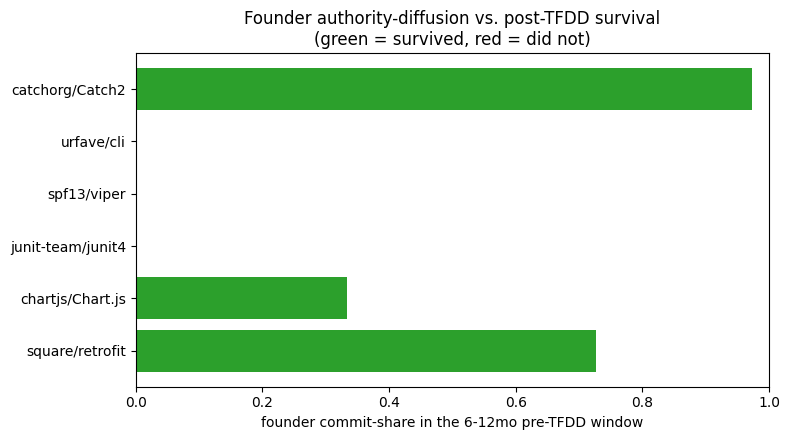


Exclusion log across the 6 demo repos: {'ok': 6}


In [10]:
print(f"{'repo':<22}{'founder_share':>15}{'n_doa_owners':>14}{'survival':>10}{'commits_at_tfdd':>17}")
for r in with_tfdd:
    print(f"{r.repo:<22}{r.founder_share:>15.3f}{r.n_doa_owners:>14}{r.binary_survival:>10}{r.commits_at_tfdd:>17}")

if with_tfdd:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    repos = [r.repo for r in with_tfdd]
    shares = [r.founder_share for r in with_tfdd]
    colors = ["#2ca02c" if r.binary_survival == 1 else "#d62728" for r in with_tfdd]
    ax.barh(repos, shares, color=colors)
    ax.set_xlabel("founder commit-share in the 6-12mo pre-TFDD window")
    ax.set_title("Founder authority-diffusion vs. post-TFDD survival\n(green = survived, red = did not)")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("No repos in this demo subset produced a usable founder-only TFDD.")

print("\nExclusion log across the 6 demo repos:", exclusion_log)